In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 02a


## Implementation of Single Layer

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align = "left"/>

## 1. Import Statements

In [2]:
###-----------------
### Import Libraries
###-----------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Setup Global Parameters

In [3]:
###----------------
### Some parameters
###----------------

# Directory locations
inpDir = '../../input'
outDir = '../output'

RANDOM_STATE = 24 # REMEMBER: to remove at the time of promotion to production
#np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

NOISE = 0.2
EPOCHS = 200  # number of epochs
ALPHA = 0.001  # learning rate
N_SAMPLES = 1000

# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'medium',
          'axes.titlesize':'medium',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## 3. Generate Data Set
<div style="font-family: Arial; font-size:1.2em;">
Sklearn's dataset generator is good source of data for learning. To keep the example simple, I'll suggest  <a href="http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html">make_moon</a> dataset generator.
</div>

In [4]:
X, y = datasets.make_moons(n_samples=N_SAMPLES, 
                           shuffle=True, 
                           noise=NOISE, 
                           random_state=RANDOM_STATE)
X[:5], y[:5]

(array([[ 0.90633951,  0.90267624],
        [-1.11536828,  0.75579289],
        [ 1.88769158,  0.4175967 ],
        [-0.93345034, -0.02299851],
        [-0.96872877,  0.06396285]]),
 array([0, 0, 1, 0, 0]))

## 4. Visualization
<p style="font-family: Arial; font-size:1.2em;">
DataFrames are easier to visualize
</p>

In [5]:
data_df = pd.DataFrame(X, columns = ['A', 'B'])

data_df['target'] = y

data_df.head()

,A,B,target
0,0.906340,0.902676,0
1,-1.115368,0.755793,0
2,1.887692,0.417597,1
3,-0.933450,-0.022999,0
4,-0.968729,0.063963,0


In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1000 non-null   float64
 1   B       1000 non-null   float64
 2   target  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [7]:
data_df.describe() # Generate descriptive statistic

,A,B,target
count,1000.000000,1000.000000,1000.00000
mean,0.490841,0.239025,0.50000
std,0.898951,0.540082,0.50025
min,-1.688795,-0.955280,0.00000
25%,-0.149565,-0.205090,0.00000
50%,0.500100,0.241163,0.50000
75%,1.095048,0.680394,1.00000
max,2.419113,1.612075,1.00000


In [8]:
# what labels are present?
data_df.target.unique()

array([0, 1])

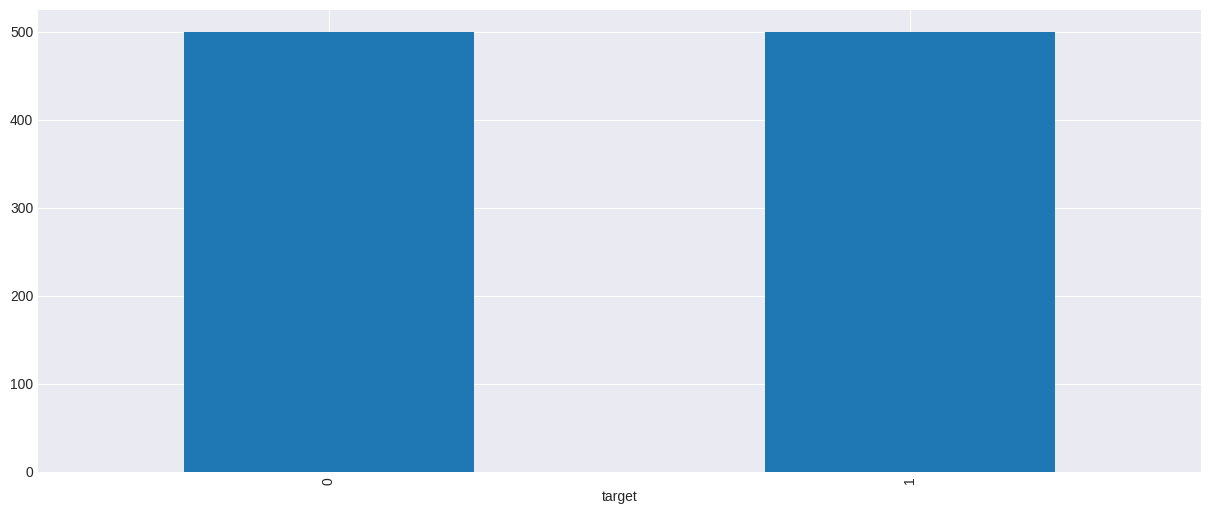

In [9]:
fig, ax = plt.subplots() # Instantiate
    
data_df['target'].value_counts().plot(ax=ax, kind='bar');

### 4.1 Different ways of plotting data

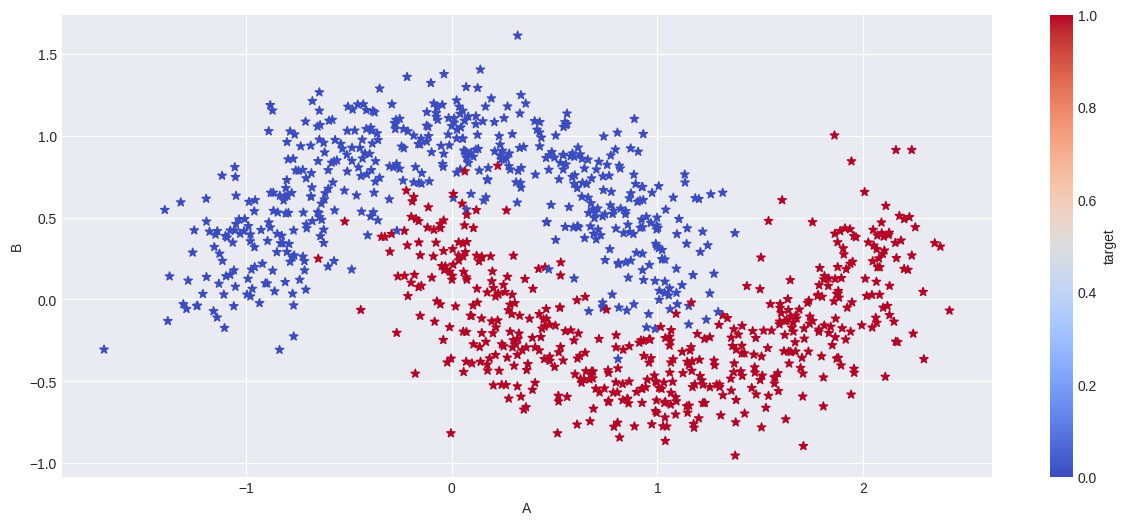

In [10]:
# Plot the data
data_df.plot.scatter('A', 'B', 
                     s=40,
                     marker = '*', 
                     c = 'target',
                     cmap=CMAP);

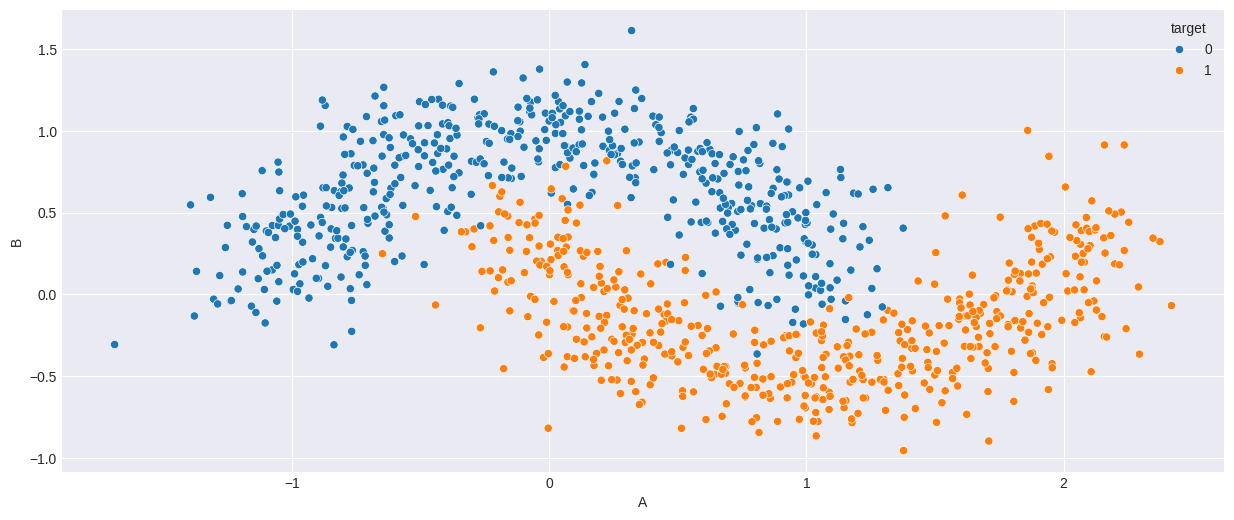

In [11]:
# Using Seaborn
ax = sns.scatterplot(x='A', y='B', data=data_df, hue='target');

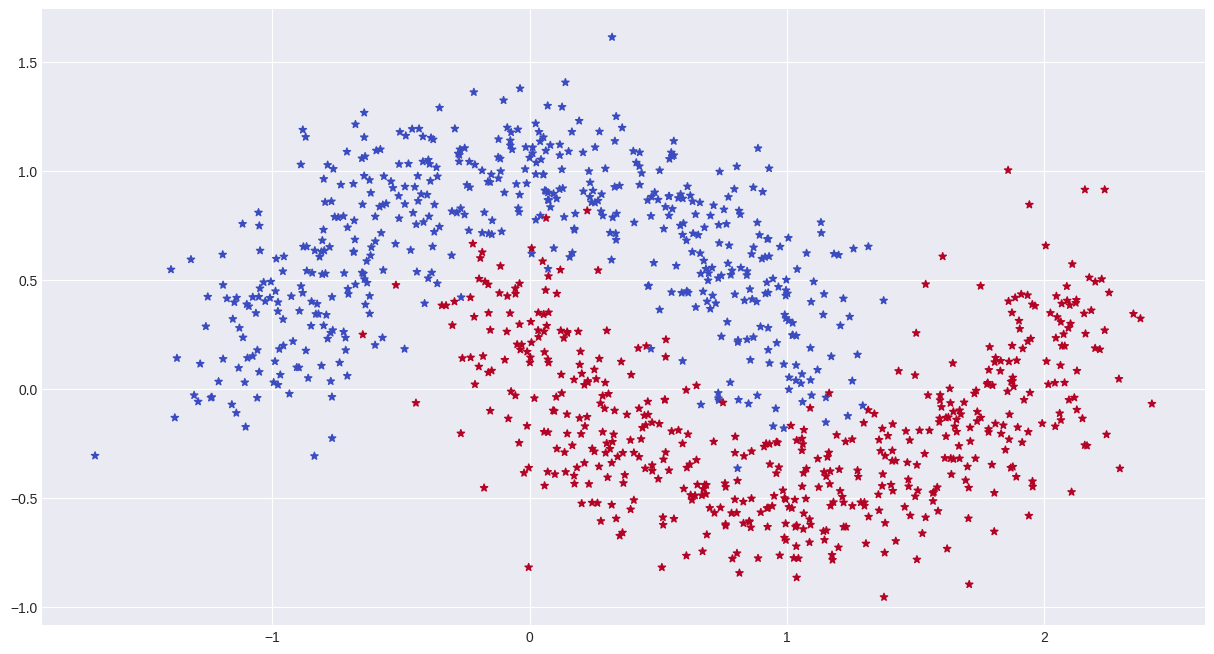

In [12]:
#### In case you want to plot X Array directly
plt.figure(figsize = (15,8))
plt.scatter(X[:,0], X[:,1], s=30, c=y, marker = '*', cmap=CMAP);

<div style="font-family: Arial; font-size:1.2em;">
    We will keep 10%, i.e. 100 records for testing and remaining records will be used in training. Note that the data is already random.
</div>

- Assumes data is already shuffled (it is, but this is fragile)
- Hardcoded split size (900/100)for demo purpose only. Generally used for timestamped data.
- No stratification - class distribution may not be preserved, may be an issue

In [13]:
data_train, data_test = data_df.to_numpy()[:900], data_df.to_numpy()[900:]

print (data_train.shape, data_test.shape)

print (type(data_train), type(data_test))

(900, 3) (100, 3)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


# Over to Perceptron

<div style="font-family: Arial; font-size:1.1em;">

Our output is binary. To keep the code in line with what we discussed in previous lecture, we will simply output 1 for positive values of 'z' and zero for negative values.
</div>

<img src="../../images/dnn_nb_s03_fig1.jpg" width='350' align = 'left'>


$$
\begin{aligned}
z & = 1.0 \circ w_0 + x_1 \circ w_1 + x_2 \circ w_2 \\
\mathrm{or}\\
z & = X\circ W \\
\end{aligned}
$$
<br/>


$$
\begin{equation*}
    \hat{y} = \begin{cases}
      1.0, & \text{for z>=0}\  \\
      0.0, & \text{for z<0}\
    \end{cases}
\end{equation*}
$$

As we know that adjustments in the weights are ($\hat{y}$ - y) or (a-y). We don't want to adjust by full value. It makes convergence easier if we adjust by a small fraction.
- **Why?** We would know better all through this module. We will circle back to `learning_rate` after some sessions.

Let's assume that adjusting weights by $\alpha$ * ( a - y ) makes better sense.
**Note:** Take learning_rate ($\alpha$) as some constant.

## 5. Prediction

In [14]:
# A function to make predictions

def predict(row: np.ndarray, weights : np.ndarray) -> np.int64:
    '''
    Args: 
        row: [feature1, feature2, target]  target is last element, not used here
        weights: array with first value as b(w0) and then w1 and w2.
    return:
        0 if sum is negative else 1. Simplest form of activation function.
    '''
    
    # building up z = X * W + b
    z = weights[0] # Initialize with b, bias
    
    for i in range(len(row)-1):
        
        z += weights[i + 1] * row[i] # and weights are added here to the values

    return 1 if z >=0  else 0 # simplest form of activation function

**Its advisable to test the function**

In [15]:
#Unit test
weights = np.array([0.1, 2.0, 1.0])

display(data_df.loc[0])

predict(data_df.loc[0].values, weights)

A         0.906340
B         0.902676
target    0.000000
Name: 0, dtype: float64

1

<div style="font-family: Arial; font-size:1.1em;">
    <h3>Back-propagation - Estimate Perceptron weights </h3>
<div>

$
\begin{aligned}
\partial{z}  & = a - y \\
\partial{b}  & = \partial{z} \\
\partial{w_1}  & = x_1 \circ \partial{z}\\
\partial{w_2}  & = x_2 \circ \partial{z}\\
\end{aligned}
$

$
\begin{aligned}
b & = b -  \alpha \circ \partial{b}\\
w_1  & = w_1 - \alpha \circ \partial{w_1}\\
w_2  & = w_2 - \alpha \circ \partial{w_2}\\
\end{aligned}
$

 
 ## 6. Training

#### Different way to generate weights:

- rng.standard_normal(data_train.shape[1]): Generates 3 random numbers from standard normal distribution (mean=0, std=1) - same as rng.normal(size=3)
- rng.normal(size = data_train.shape[1])
- rnd.random(data_train.shape[1]): Generates 3 random numbers from uniform distribution [0, 1)

In [16]:
rng.standard_normal(3)

array([ 1.35074732,  0.34309058, -1.16299016])

In [17]:
rng.normal(size = data_train.shape[1])

array([-0.18708582, -0.3394646 , -0.22767632])

In [18]:
rng.random(data_train.shape[1])

array([0.87411653, 0.08643046, 0.74247527])

In [ ]:
def train_weights(train: np.ndarray, 
                  alpha: float, 
                  n_epochs: int) -> tuple[list, np.ndarray]:
    '''
    Args: 
        train: training dataset
        alpha: learning rate
        n_epochs: number of epochs to train
    return:
        errors: list containing errors
        weights: list of updated weights
    '''
    
    # We will be appending errors in a list
    errors = []
    
    #Initialize Weights. In theory b can be zero. For sake of simplicity, let's initialize b as well.         
    weights = rng.standard_normal(train.shape[1])
    
    # find m; number of samples
    m = train.shape[0]
    
    for epoch in range(n_epochs): # loop for number of epochs
        
        sum_error = 0.0
        
        ###---------------------------------------------------
        ### Note: we are adjusting weights in each of the row.
        ### It is one of the techniques of optimization
        ### More optimization techniques later
        ###---------------------------------------------------
        for row in train:
            
            prediction = predict(row, weights) # make prediction by row
            
            ## calculate error and update weights (Over Simplified version of Backpropagation)
            error = prediction - row[-1] # dz = (a-y) 
            
            sum_error += error**2 # cumulative error for this epoch
            
            # In batch processing we would have updated once for every batch
            # In stochastic gradient descend, we update for each training example.
            
            weights[0] = weights[0] - alpha * error  # update b
            
            for i in range(len(row)-1):
                
                weights[i + 1] = weights[i + 1] - alpha * error * row[i] # update rest of the weights
        
        errors.append(sum_error / m) # append average error
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: Loss = {errors[-1]:.4f}")
        
    return errors, weights

In [20]:
# calling 'train_weight'

errors, weights = train_weights(data_train, ALPHA, EPOCHS)

print(f'\nW0: {weights[0]:.6f}, W1: {weights[1]:.6f}, W2: {weights[2]:.6f}')

Epoch   0: Loss = 0.6289
Epoch  10: Loss = 0.1389
Epoch  20: Loss = 0.1400
Epoch  30: Loss = 0.1456
Epoch  40: Loss = 0.1800
Epoch  50: Loss = 0.1811
Epoch  60: Loss = 0.1822
Epoch  70: Loss = 0.1822
Epoch  80: Loss = 0.1844
Epoch  90: Loss = 0.1844
Epoch 100: Loss = 0.1778
Epoch 110: Loss = 0.1867
Epoch 120: Loss = 0.1767
Epoch 130: Loss = 0.1822
Epoch 140: Loss = 0.1822
Epoch 150: Loss = 0.1800
Epoch 160: Loss = 0.1733
Epoch 170: Loss = 0.1822
Epoch 180: Loss = 0.1867
Epoch 190: Loss = 0.1811

W0: -0.000345, W1: 0.002280, W2: -0.003722


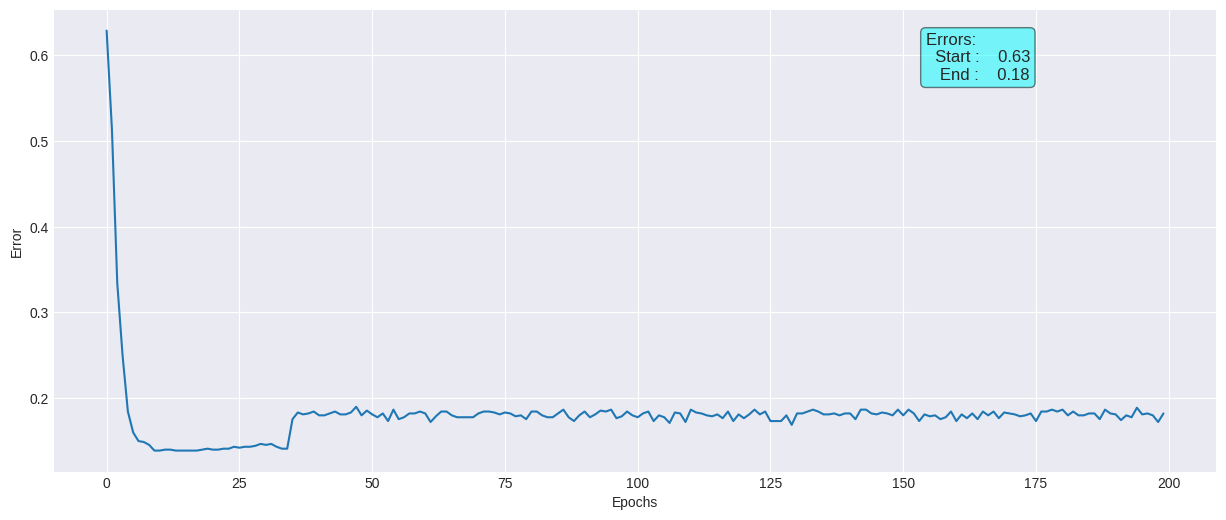

In [21]:
fig, ax = plt.subplots()
ax.plot(errors)

# Little beautification
txtstr = "Errors: \n  Start : {:7.2f}\n   End : {:7.2f}".format(errors[0],errors[-1]) #text to plot

# Properties  matplotlib.patch.Patch 
props = dict(boxstyle='round', facecolor='cyan', alpha=0.5)

# Place a text box in upper left in axes coords

ax.text(0.75, 0.95,                      # place text at 75% from left, 95% from bottom (in Axes fraction coords)
        txtstr,                          # text
        transform=ax.transAxes,          # interpret (x, y) as fractions of Axes size (0–1 range)
        fontsize=12,                     # set font size
        verticalalignment='top',         # align top of text box to the given y position
        bbox=props)                      # draw a surrounding box using style properties defined in 'props' (e.g., facecolor, alpha)


# Labeling the Plot
ax.set_xlabel("Epochs")
ax.set_ylabel("Error");

## Question
<div style="font-family: Arial; font-size:1.2em;">
Why do we keep training and not stop at min training error? Hold on! We would get to that eventually.
</div>

## 7. Predictions

### Train Set

In [22]:
predictions = []

for row in data_train:
    
    prediction = predict(row, weights)
    
    predictions.append(prediction)

In [23]:
accuracy_score(data_train[:,-1], predictions)

0.8388888888888889

In [24]:
cm = confusion_matrix(data_train[:,-1], predictions)
cm

array([[372,  70],
       [ 75, 383]])

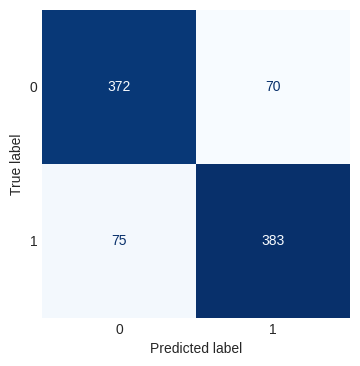

In [25]:
# Create plot object of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])

# initialize figure
fig, ax = plt.subplots(figsize = (4,4))

#Plot 
disp.plot(ax = ax, cmap = 'Blues', colorbar=False)
plt.grid()
plt.show();

### Test Set

In [26]:
predictions = []

for row in data_test:
    
    prediction = predict(row, weights)
    
    predictions.append(prediction)

In [27]:
accuracy_score(data_test[:,-1], predictions)

0.89

In [28]:
cm = confusion_matrix(data_test[:,-1], predictions)
cm

array([[54,  4],
       [ 7, 35]])

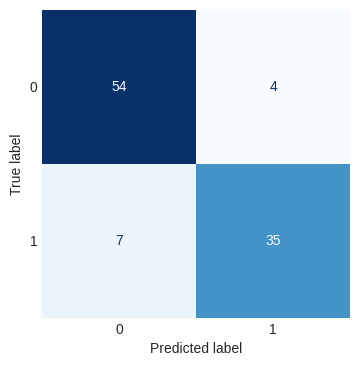

In [29]:
# Create plot object of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])

# initialize figure
fig, ax = plt.subplots(figsize = (4,4))

#Plot 
disp.plot(ax = ax, cmap = 'Blues', colorbar=False)
plt.grid()
plt.show();

In [30]:
def fn_plot_decision_boundary(X: np.ndarray):
    
    # initialize the figure
    fig, ax = plt.subplots(figsize = (8,5))
    
    # Small increment to create object function surface
    dm = 0.01
    margin = 10*dm
    # Range of X values (First feature)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    
    # Range of Y values (Second feature)
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Create a grid to evaluate the object function
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))
    
    # flatten and stack
    # arrays will be stacked along their last axis after being upgraded to at least 2-D 
    # with 1’s post-pended to the shape (column vectors made out of 1-D arrays)
    XX = np.c_[xx.ravel(), yy.ravel()] 

    # add another column filled with 1 to make it work with the predict function
    XX = np.hstack( ( XX, np.ones((XX.shape[0],1)) ) )
    
    # list to collect predictions
    y_pred = []
    
    # Iterate over rows
    for row in (XX):

        y_p = predict(row, weights)
        y_pred.append(y_p)
        
    Z = np.array(y_pred).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=X[:, 2],
                                  s=20, edgecolor='k', cmap=plt.cm.bwr)
    ax.set_title('Decision Boundary')

    ax.set_xlabel('A')
    ax.set_ylabel('B')
    plt.show()

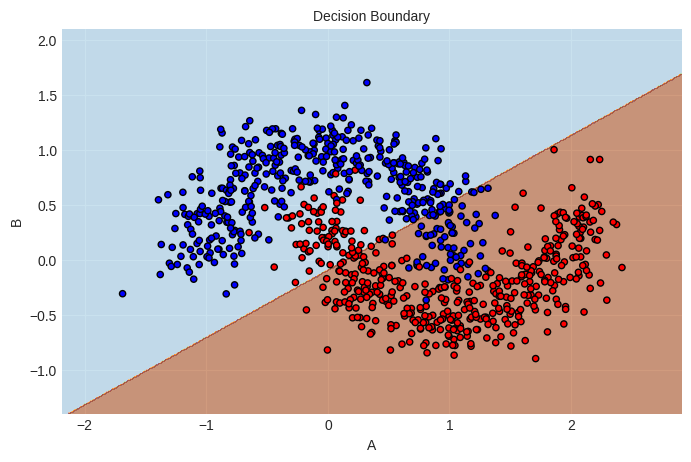

In [31]:
fn_plot_decision_boundary(data_train)

## Tracking
<div style="font-family: Arial; font-size:1.2em;">
Lets track the results across various implementations...

 |#|Implementation|Training Accuracy|Testing Accuracy|Remarks|
 |:-:|---|---|---|---|
 |1|Simple Perceptron|0.83111|0.89000||

## Notes:

## A note on Loss Function

In logistic regression, we model the probability that an input belongs to a particular class.

We treat the model’s output, $\hat{y}$, as the probability that the correct answer is yes (i.e., $y = 1$), given the input $X$:

$\hat{y}=p( y = 1 \mid X)$

**Example:**
Suppose we want to check if there is a car in a picture. Then, $\hat{y}$ is the probability that the picture has a car.

Mathematically:
If $X$ is a training example (like the picture), then
$\hat{y}=p(y=1 \mid X)$

This means we are asking: "What is the chance that the answer is yes (there is a car), given this picture?"

Two possible cases:
* If there is a car in the picture ($y = 1$), then : $p(y \mid X)=\hat{y}$
* If there is no car in the picture ($y = 0$), then : $p(y \mid X)=1−\hat{y}$

<b>Combining Both Cases into One Equation:</b>

For binary classification with $y \in \{0,1\}$ and predicted probability $\hat{y} \in (0,1)$:

$p(y \mid X)$ = $\hat{y}^{y} * (1 - \hat{y}) ^{(1-y)}$

#### Verification:
* If $y = 1$, the formula becomes: $\hat{y}^1 \cdot (1 - \hat{y})^0 = \hat{y}$
* If $y = 0$, it becomes: $\hat{y}^0 \cdot (1 - \hat{y})^1 = 1 - \hat{y}$
So this one formula covers both cases.

####  Taking the Logarithm

Taking the log transforms the product into a sum:
$\log⁡[p(y \mid X)]=y \cdot \log⁡(\hat{y}) + (1 − y) \cdot \log⁡(1 − \hat{y})$

### Defining the Loss Function

Loss is the negative log-likelihood:

$L(\hat{y},y)=−[y \cdot \log⁡(\hat{y})+(1−y) \cdot \log⁡(1−\hat{y})]$

This is called the **binary cross-entropy loss **function.

**Note:** Sometimes, $\hat{y}$ is also written as $a$ (for activation), so the formula may also be written as:

$
\begin{aligned}
L(a,y) =  - [ y \cdot \log ( a ) + ( 1 - y ) \cdot \log( 1 - a ) ]\\
\end{aligned}
$

|Case| y |Loss = -log(a) if y=1 else -log(1-a)| a |-log(a)|-log(1-a)|
|:-: |:-:|:-: |:-:|  :-: |   :-:  |
| 1  | 0 | -log( 1 - a )| 0.000001 |13.8155|**1 e-6**|
| 2  | 0 | -log( 1 - a )| 0.999999 |1 e-6|**13.8155**|
| 3  | 1 | -log( a )| 0.000001 |**13.8155**|1 e-6|
| 4  | 1 | -log( a )| 0.999999 |**1 e-6**|13.8155|


We want to sum it up for all samples in the dataset. Hence:

$
\begin{aligned}
p(\text{all labels} \mid \text{all inputs}) & =  \prod_{i=1}^m p(y^{(i)}|x^{(i)})\\
\log \left[ p(\text{all labels} \mid \text{all inputs}) \right] & =  \log \left[ \prod_{i=1}^m p(y^{(i)}|x^{(i)}) \right]\\
& =  \sum_{i=1}^m \log \left[ p(y^{(i)}|x^{(i)}) \right]
\end{aligned}
$

For multi-class classification with K classes, we use:

$
\begin{aligned}
&\text{Softmax activation: }ŷ_j = \frac{e^{z_j}}{ \sum_{j=1}^{K} e^{z_k}}\\
&\text{J (cross-entropy loss)} =  - \sum_{i=1}^m \sum_{j=1}^K[ y_{i,j} * log(\hat{y}_{i,j} )]\\
&\text{Divide it by m to normalize  and make it independent of dataset size}\\
& \text{J (cross-entropy loss)} = - \frac{1}{m} * \sum_{i=1}^m \sum_{j=1}^K [ y_{i,j} * log(\hat{y}_{i,j}) ]\\
\end{aligned}
$

### Introducing $\mathrm{sigmoid}$ function for our binary output.
#### For a Single Sample
**Forward Pass**

$
\begin{align}
z = x_1 \cdot w_1 + x_2 \cdot w_2 + b \\
a = \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}\\
\end{align}
$
**Gradients**

$
\begin{align}
dz &= (a - y) \\
db &= dz\\
dw_1 &= x_1 \cdot dz\\
dw_2 &= x_2 \cdot dz\\
\end{align}
$
**Updates**
$
\begin{align}
b &= b - \alpha \cdot db\\
w_1 &= w_1 - \alpha \cdot dw_1\\
w_2 &= w_2 - \alpha \cdot dw_2\\
\end{align}
$
### Sigmoid function
$
\begin{align}
a &= \sigma(z)\\
&= \dfrac{1}{1 + e^{-z}}\\
\end{align}
$

## Derivative of sigmoid function
$
\begin{align}
\partial{a} &= \partial{\sigma(z)}\\
&= \dfrac{\partial}{\partial{z}} \left[ \dfrac{1}{1 + e^{-z}} \right] \\
&= \dfrac{\partial}{\partial{z}} \left( 1 + \mathrm{e}^{-z} \right)^{-1} \\
&= -(1 + e^{-z})^{-2}(-e^{-z}) \\
&= \dfrac{e^{-z}}{\left(1 + e^{-z}\right)^2} \\
&= \dfrac{1}{1 + e^{-z}\ } \cdot \dfrac{e^{-z}}{1 + e^{-z}}  \\
&= \dfrac{1}{1 + e^{-z}\ } \cdot \dfrac{(1 + e^{-z}) - 1}{1 + e^{-z}}  \\
&= \dfrac{1}{1 + e^{-z}\ } \cdot \left[ \dfrac{1 + e^{-z}}{1 + e^{-z}} - \dfrac{1}{1 + e^{-z}} \right] \\
&= \dfrac{1}{1 + e^{-z}\ } \cdot \left[ 1 - \dfrac{1}{1 + e^{-z}} \right] \\
&= \sigma(z) \cdot (1 - \sigma(z))\\
&= a \cdot (1 - a)
\end{align}
$